# Frailty recovery diagnostic

This notebook summarizes the completed `frailty-recovery-diagnostic` experiment. It asks two questions:

1. Does DVFM recover the known subject-level frailty?
2. Does that recovery translate into useful event-time prediction?

Results cover Gaussian shared frailty and Clayton Gamma frailty, with five independent sampling, split, and model seeds per mechanism. Error bars below are standard deviations across repeats.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd()
if not (ROOT / "results" / "frailty-recovery-diagnostic").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "results" / "frailty-recovery-diagnostic"

predictions = pd.read_csv(RESULTS / "results_raw.csv")
recovery = pd.read_csv(RESULTS / "frailty_recovery.csv")
subjects = pd.read_csv(RESULTS / "subject_latent_diagnostics.csv.gz")

MECHANISM_LABELS = {
    "gaussian_shared_frailty": "Gaussian shared frailty",
    "clayton_gamma_frailty": "Clayton Gamma frailty",
}
VARIANT_LABELS = {
    "current": "Current: fixed 200 epochs",
    "checkpoint_fix": "Best reconstruction NLL",
    "old_training": "Legacy schedule",
    "schedule_isolation": "Schedule isolation",
}
print(f"Loaded {len(predictions):,} predictive rows and {len(subjects):,} subject-level rows.")

Loaded 200 predictive rows and 212,960 subject-level rows.


## Subject-level frailty recovery

The scatterplots use the current DVFM configuration at its final, 200-epoch checkpoint. Posterior means are aligned and linearly calibrated using validation data only; the plotted subjects are from the held-out test partition.

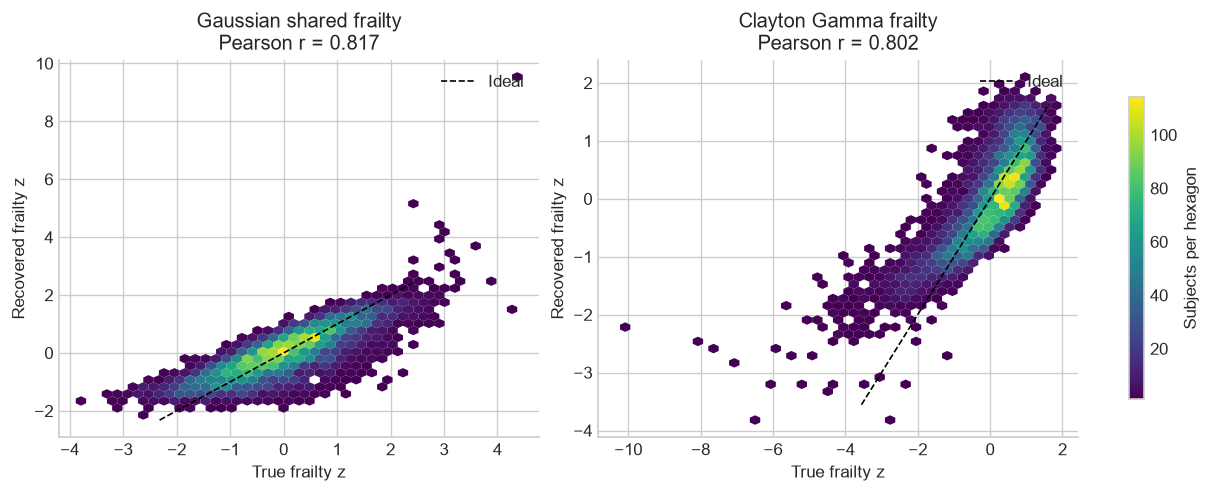

In [2]:
current_subjects = subjects.query(
    "architecture == 'dvfm' and training_variant == 'current' and checkpoint == 'final' and split == 'test'"
).copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, (mechanism, label) in zip(axes, MECHANISM_LABELS.items()):
    part = current_subjects[current_subjects["mechanism"] == mechanism]
    image = ax.hexbin(
        part["true_z"], part["frailty_z_calibrated"],
        gridsize=42, mincnt=1, cmap="viridis", linewidths=0,
    )
    limits = np.nanpercentile(
        np.r_[part["true_z"], part["frailty_z_calibrated"]], [0.5, 99.5]
    )
    ax.plot(limits, limits, "--", color="black", linewidth=1, label="Ideal")
    correlation = part[["true_z", "frailty_z_calibrated"]].corr().iloc[0, 1]
    ax.set(title=f"{label}\nPearson r = {correlation:.3f}", xlabel="True frailty z", ylabel="Recovered frailty z")
    ax.legend(frameon=False)
fig.colorbar(image, ax=axes, label="Subjects per hexagon", shrink=0.8)
plt.show()

In [3]:
primary_recovery = recovery.query(
    "architecture == 'dvfm' and is_primary_checkpoint == True and split == 'test' and subgroup == 'all'"
).copy()

recovery_summary = primary_recovery.groupby(["mechanism", "training_variant"]).agg(
    pearson_mean=("frailty_pearson", "mean"), pearson_sd=("frailty_pearson", "std"),
    spearman_mean=("frailty_spearman", "mean"), spearman_sd=("frailty_spearman", "std"),
    rmse_mean=("frailty_rmse_calibrated", "mean"), rmse_sd=("frailty_rmse_calibrated", "std"),
    tau_error_mean=("absolute_conditional_kendall_tau_error", "mean"),
).reset_index()
recovery_summary["Mechanism"] = recovery_summary["mechanism"].map(MECHANISM_LABELS)
recovery_summary["Training/checkpoint"] = recovery_summary["training_variant"].map(VARIANT_LABELS)
for output, mean, sd in [
    ("Pearson r", "pearson_mean", "pearson_sd"),
    ("Spearman rho", "spearman_mean", "spearman_sd"),
    ("Calibrated RMSE", "rmse_mean", "rmse_sd"),
]:
    recovery_summary[output] = recovery_summary.apply(
        lambda row: f"{row[mean]:.3f} ± {row[sd]:.3f}", axis=1
    )
recovery_summary["Absolute tau error"] = recovery_summary["tau_error_mean"].map(lambda value: f"{value:.3f}")

display(recovery_summary[[
    "Mechanism", "Training/checkpoint", "Pearson r", "Spearman rho",
    "Calibrated RMSE", "Absolute tau error",
]].sort_values(["Mechanism", "Training/checkpoint"]).reset_index(drop=True))

,Mechanism,Training/checkpoint,Pearson r,Spearman rho,Calibrated RMSE,Absolute tau error
0,Clayton Gamma frailty,Best reconstruction NLL,0.769 ± 0.008,0.787 ± 0.006,0.647 ± 0.034,0.155
1,Clayton Gamma frailty,Current: fixed 200 epochs,0.803 ± 0.004,0.801 ± 0.006,0.604 ± 0.026,0.059
2,Clayton Gamma frailty,Legacy schedule,0.689 ± 0.129,0.716 ± 0.157,0.719 ± 0.105,0.409
3,Clayton Gamma frailty,Schedule isolation,0.773 ± 0.008,0.791 ± 0.011,0.642 ± 0.031,0.258
4,Gaussian shared frailty,Best reconstruction NLL,0.766 ± 0.087,0.804 ± 0.008,0.675 ± 0.150,0.237
5,Gaussian shared frailty,Current: fixed 200 epochs,0.817 ± 0.006,0.813 ± 0.005,0.587 ± 0.013,0.049
6,Gaussian shared frailty,Legacy schedule,0.681 ± 0.268,0.801 ± 0.009,0.829 ± 0.485,0.311
7,Gaussian shared frailty,Schedule isolation,0.806 ± 0.017,0.807 ± 0.008,0.603 ± 0.022,0.312


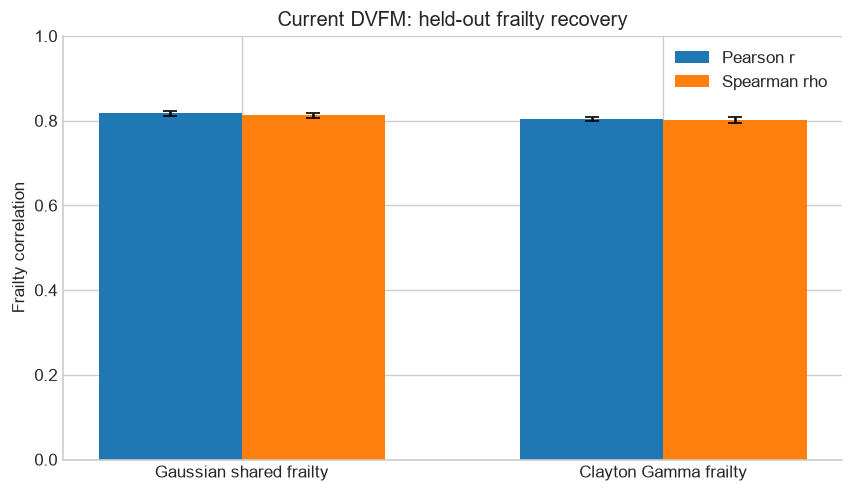

In [4]:
current_recovery = primary_recovery[primary_recovery["training_variant"] == "current"]
summary = current_recovery.groupby("mechanism").agg(
    pearson=("frailty_pearson", "mean"), pearson_sd=("frailty_pearson", "std"),
    spearman=("frailty_spearman", "mean"), spearman_sd=("frailty_spearman", "std"),
).reindex(MECHANISM_LABELS)

x = np.arange(len(summary))
width = 0.34
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.bar(x - width / 2, summary["pearson"], width, yerr=summary["pearson_sd"], capsize=4, label="Pearson r")
ax.bar(x + width / 2, summary["spearman"], width, yerr=summary["spearman_sd"], capsize=4, label="Spearman rho")
ax.set(xticks=x, xticklabels=[MECHANISM_LABELS[key] for key in summary.index], ylim=(0, 1), ylabel="Frailty correlation", title="Current DVFM: held-out frailty recovery")
ax.legend(frameon=False)
plt.show()

## Predictive performance

DVFM population prediction integrates over either the prior or aggregate training posterior. The oracle decoder is included as an upper-bound diagnostic: `oracle subject z` supplies each test subject's true frailty, whereas `empirical train true z` integrates over the training frailty distribution and is a population prediction.

In [5]:
dvfm_prediction = predictions.query(
    "architecture == 'dvfm' and training_variant == 'current' and checkpoint == 'final'"
).copy()
dvfm_prediction["method"] = dvfm_prediction["prediction_mode"].map({
    "prior": "DVFM: prior",
    "aggregate_posterior": "DVFM: aggregate posterior",
})
oracle_prediction = predictions.query(
    "architecture == 'oracle_z_decoder' and is_primary_checkpoint == True"
).copy()
oracle_prediction["method"] = oracle_prediction["prediction_mode"].map({
    "empirical_train_true_z": "Oracle decoder: population z",
    "oracle_subject_z": "Oracle decoder: subject z",
})
prediction_focus = pd.concat([dvfm_prediction, oracle_prediction], ignore_index=True)

prediction_summary = prediction_focus.groupby(["mechanism", "method"]).agg(
    ibs_mean=("oracle_ibs", "mean"), ibs_sd=("oracle_ibs", "std"),
    ci_mean=("oracle_ci", "mean"), ci_sd=("oracle_ci", "std"),
    mae_mean=("oracle_mae", "mean"), mae_sd=("oracle_mae", "std"),
).reset_index()
prediction_summary["Mechanism"] = prediction_summary["mechanism"].map(MECHANISM_LABELS)
for output, mean, sd in [
    ("Oracle IBS ↓", "ibs_mean", "ibs_sd"),
    ("Oracle CI ↑", "ci_mean", "ci_sd"),
    ("Oracle MAE ↓", "mae_mean", "mae_sd"),
]:
    prediction_summary[output] = prediction_summary.apply(
        lambda row: f"{row[mean]:.3f} ± {row[sd]:.3f}", axis=1
    )
display(prediction_summary[[
    "Mechanism", "method", "Oracle IBS ↓", "Oracle CI ↑", "Oracle MAE ↓",
]].rename(columns={"method": "Prediction"}).sort_values(["Mechanism", "Prediction"]).reset_index(drop=True))

,Mechanism,Prediction,Oracle IBS ↓,Oracle CI ↑,Oracle MAE ↓
0,Clayton Gamma frailty,DVFM: aggregate posterior,0.106 ± 0.002,0.715 ± 0.004,0.614 ± 0.019
1,Clayton Gamma frailty,DVFM: prior,0.106 ± 0.001,0.715 ± 0.005,0.611 ± 0.020
2,Clayton Gamma frailty,Oracle decoder: population z,0.104 ± 0.002,0.718 ± 0.003,0.604 ± 0.024
3,Clayton Gamma frailty,Oracle decoder: subject z,0.056 ± 0.002,0.845 ± 0.003,0.357 ± 0.024
4,Gaussian shared frailty,DVFM: aggregate posterior,0.118 ± 0.007,0.625 ± 0.006,2.659 ± 0.081
5,Gaussian shared frailty,DVFM: prior,0.116 ± 0.007,0.625 ± 0.008,2.659 ± 0.081
6,Gaussian shared frailty,Oracle decoder: population z,0.114 ± 0.005,0.625 ± 0.008,2.652 ± 0.091
7,Gaussian shared frailty,Oracle decoder: subject z,0.059 ± 0.003,0.836 ± 0.006,1.957 ± 0.108


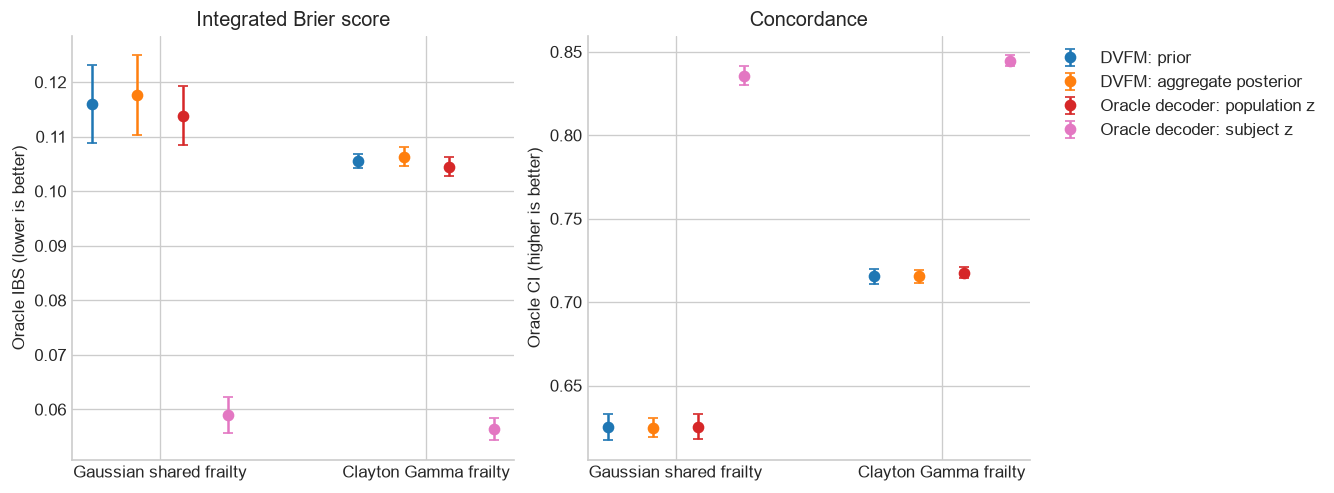

In [6]:
methods = [
    "DVFM: prior", "DVFM: aggregate posterior",
    "Oracle decoder: population z", "Oracle decoder: subject z",
]
colors = plt.cm.tab10(np.linspace(0, 0.6, len(methods)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, metric, error, title, ylabel in [
    (axes[0], "ibs_mean", "ibs_sd", "Integrated Brier score", "Oracle IBS (lower is better)"),
    (axes[1], "ci_mean", "ci_sd", "Concordance", "Oracle CI (higher is better)"),
]:
    for offset, (method, color) in enumerate(zip(methods, colors)):
        part = prediction_summary[prediction_summary["method"] == method].set_index("mechanism").reindex(MECHANISM_LABELS)
        positions = np.arange(len(MECHANISM_LABELS)) + (offset - 1.5) * 0.17
        ax.errorbar(positions, part[metric], yerr=part[error], fmt="o", capsize=3, color=color, label=method)
    ax.set(xticks=np.arange(len(MECHANISM_LABELS)), xticklabels=list(MECHANISM_LABELS.values()), title=title, ylabel=ylabel)
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## Reading the diagnostic

Strong retrospective frailty correlation shows that DVFM can infer subject-level latent risk from `(x, observed time, event indicator)`. Population prediction is a different task because an unseen subject's frailty is unavailable and must be integrated out. The gap to the oracle-subject decoder quantifies the predictive information carried by the true individual frailty; it should not be interpreted as an attainable population-prediction baseline.